In [43]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import pytesseract as pt
import plotly.express as px
import matplotlib.pyplot as plt
import xml.etree.ElementTree as xet

from glob import glob
from skimage import io
from shutil import copy
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import TensorBoard
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.layers import Dense, Dropout, Flatten, Input
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [44]:
import tensorflow as tf
print(tf.__version__)

2.10.0


In [45]:
path = glob('/Users/kayyu/Desktop/Py/ANPR/images/*.xml')
labels_dict = dict(filepath=[],xmin=[],xmax=[],ymin=[],ymax=[])
for filename in path:

    info = xet.parse(filename)
    root = info.getroot()
    member_object = root.find('object')
    labels_info = member_object.find('bndbox')
    xmin = int(labels_info.find('xmin').text)
    xmax = int(labels_info.find('xmax').text)
    ymin = int(labels_info.find('ymin').text)
    ymax = int(labels_info.find('ymax').text)

    labels_dict['filepath'].append(filename)
    labels_dict['xmin'].append(xmin)
    labels_dict['xmax'].append(xmax)
    labels_dict['ymin'].append(ymin)
    labels_dict['ymax'].append(ymax)

In [46]:
df = pd.DataFrame(labels_dict)
df.to_csv('labels.csv',index=False)
df.head()

,filepath,xmin,xmax,ymin,ymax
0,/Users/kayyu/Desktop/Py/ANPR/images\AP1.xml,101,179,145,162
1,/Users/kayyu/Desktop/Py/ANPR/images\AP10.xml,111,188,267,284
2,/Users/kayyu/Desktop/Py/ANPR/images\AP12.xml,77,132,226,248
3,/Users/kayyu/Desktop/Py/ANPR/images\AP13.xml,96,169,191,210
4,/Users/kayyu/Desktop/Py/ANPR/images\AP14.xml,103,191,176,206


In [47]:
filename = df['filepath'][0]
def getFilename(filename):
    filename_image = xet.parse(filename).getroot().find('filename').text
    filepath_image = os.path.join('/Users/kayyu/Desktop/Py/ANPR/images',filename_image)
    return filepath_image
getFilename(filename)

'/Users/kayyu/Desktop/Py/ANPR/images\\AP1.jpg'

In [48]:
image_path = list(df['filepath'].apply(getFilename))
image_path[:10]#random check

['/Users/kayyu/Desktop/Py/ANPR/images\\AP1.jpg',
 '/Users/kayyu/Desktop/Py/ANPR/images\\AP10.jpg',
 '/Users/kayyu/Desktop/Py/ANPR/images\\AP12.jpg',
 '/Users/kayyu/Desktop/Py/ANPR/images\\AP13.jpg',
 '/Users/kayyu/Desktop/Py/ANPR/images\\AP14.jpg',
 '/Users/kayyu/Desktop/Py/ANPR/images\\AP15.jpg',
 '/Users/kayyu/Desktop/Py/ANPR/images\\AP16.jpg',
 '/Users/kayyu/Desktop/Py/ANPR/images\\AP17.jpg',
 '/Users/kayyu/Desktop/Py/ANPR/images\\AP18.jpg',
 '/Users/kayyu/Desktop/Py/ANPR/images\\AP19.jpg']

Image: /Users/kayyu/Desktop/Py/ANPR/images/AP1.jpg
Shape: (204, 272, 3)
BBOX: 101 145 179 162


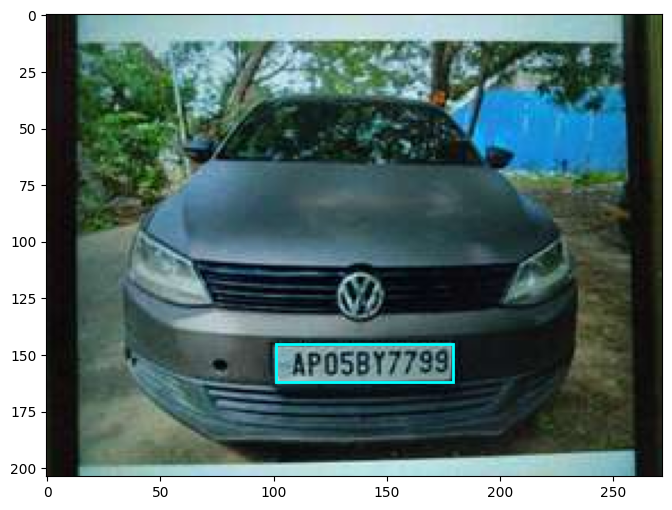

In [49]:
xml_file = df['filepath'][0]  # ensure df is correct
tree = xet.parse(xml_file)
root = tree.getroot()

filename_image = root.find('filename').text
img_path = f"/Users/kayyu/Desktop/Py/ANPR/images/{filename_image}"

img = io.imread(img_path)

bbox = root.find('object').find('bndbox')
xmin = int(bbox.find('xmin').text)
ymin = int(bbox.find('ymin').text)
xmax = int(bbox.find('xmax').text)
ymax = int(bbox.find('ymax').text)

print("Image:", img_path)
print("Shape:", img.shape)
print("BBOX:", xmin, ymin, xmax, ymax)

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.gca().add_patch(plt.Rectangle((xmin, ymin),
                                  xmax-xmin,
                                  ymax-ymin,
                                  fill=False,
                                  edgecolor='cyan',
                                  linewidth=2))
plt.show()


In [50]:
#Targeting all our values in array selecting all columns
labels = df.iloc[:,1:].values
data = []
output = []
for ind in range(len(image_path)):
    image = image_path[ind]
    img_arr = cv2.imread(image)
    h,w,d = img_arr.shape
    # Prepprocesing
    load_image = load_img(image,target_size=(224,224))
    load_image_arr = img_to_array(load_image)
    norm_load_image_arr = load_image_arr/255.0 # Normalization
    # Normalization to labels
    xmin,xmax,ymin,ymax = labels[ind]
    nxmin,nxmax = xmin/w,xmax/w
    nymin,nymax = ymin/h,ymax/h
    label_norm = (nxmin,nxmax,nymin,nymax) # Normalized output
    # Append
    data.append(norm_load_image_arr)
    output.append(label_norm)

In [51]:
X = np.array(data,dtype=np.float32)
y = np.array(output,dtype=np.float32)

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=0)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((404, 224, 224, 3), (102, 224, 224, 3), (404, 4), (102, 4))

: 

In [ ]:
inception_resnet = InceptionResNetV2(weights="imagenet",include_top=False, input_tensor=Input(shape=(224,224,3)))
# ---------------------
headmodel = inception_resnet.output
headmodel = Flatten()(headmodel)
headmodel = Dense(500,activation="relu")(headmodel)
headmodel = Dense(250,activation="relu")(headmodel)
headmodel = Dense(4,activation='sigmoid')(headmodel)


# ---------- model
model = Model(inputs=inception_resnet.input,outputs=headmodel)

In [ ]:
# Complie model
model.compile(loss='mse',optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4))
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 111, 111, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 111, 111, 32  96         ['conv2d[0][0]']                 
 alization)                     )                                                             

In [ ]:
#tfb = TensorBoard('object_detection')
#history = model.fit(x=x_train,y=y_train,batch_size=10,epochs=70,
                    #validation_data=(x_test,y_test),callbacks=[tfb])

In [ ]:
#model.save('./object_detection.keras') 

In [ ]:
model = tf.keras.models.load_model('object_detection.keras')
print('Model loaded Sucessfully')

Model loaded Sucessfully


In [ ]:
path = '/Users/kayyu/Desktop/Py/ANPR/TEST/TEST.jpeg'

# Read image using OpenCV (BGR) and convert to RGB
image = cv2.imread(path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize the same image for prediction
image_resized = cv2.resize(image, (224, 224))
image_arr_224 = image_resized / 255.0


# Size of the orginal image
h,w,d = image.shape
print('Height of the image =',h)
print('Width of the image =',w)

Height of the image = 729
Width of the image = 901


In [ ]:
fig = px.imshow(image)
fig.update_layout(width=700, height=500,  margin=dict(l=10, r=10, b=10, t=10), xaxis_title='Figure 13 - TEST Image')

In [ ]:
image_arr_224.shape

(224, 224, 3)

In [ ]:
test_arr = image_arr_224.reshape(1,224,224,3)
test_arr.shape

(1, 224, 224, 3)

In [ ]:
# Make predictions
coords = model.predict(test_arr)
coords

1/1 [==============================] - 11s 11s/step


array([[0.35760197, 0.648117  , 0.6645846 , 0.73262346]], dtype=float32)

In [ ]:
denorm = np.array([w,w,h,h])
coords = coords * denorm
coords

array([[322.19937536, 583.95342225, 484.48215669, 534.08250082]])

In [ ]:
coords = coords.astype(np.int32)
coords

array([[322, 583, 484, 534]])

In [ ]:
xmin, xmax,ymin,ymax = coords[0]
pt1 =(xmin,ymin)
pt2 =(xmax,ymax)
print(pt1, pt2)

(322, 484) (583, 534)


In [ ]:
print("Predicted coords (raw):", coords)
print("Image shape:", image.shape)
print("pt1, pt2:", pt1, pt2)


cv2.rectangle(image,pt1,pt2,(0,255,0),3)
fig = px.imshow(image)
fig.update_layout(width=700, height=500, margin=dict(l=10, r=10, b=10, t=10))

Predicted coords (raw): [[322 583 484 534]]
Image shape: (729, 901, 3)
pt1, pt2: (322, 484) (583, 534)


In [ ]:
# Create pipeline
path = '/Users/kayyu/Desktop/Py/ANPR/TEST/TEST.jpeg'
def object_detection(path):
    
    # Read image
    image = load_img(path) # PIL object
    image = np.array(image,dtype=np.uint8) # 8 bit array (0,255)
    image1 = load_img(path,target_size=(224,224))
    
    # Data preprocessing
    image_arr_224 = img_to_array(image1)/255.0 # Convert to array & normalized
    h,w,d = image.shape
    test_arr = image_arr_224.reshape(1,224,224,3)
    
    # Make predictions
    coords = model.predict(test_arr)
    
    # Denormalize the values
    denorm = np.array([w,w,h,h])
    coords = coords * denorm
    coords = coords.astype(np.int32)
    
    # Draw bounding on top the image
    xmin, xmax,ymin,ymax = coords[0]
    pt1 =(xmin,ymin)
    pt2 =(xmax,ymax)
    print(pt1, pt2)
    cv2.rectangle(image,pt1,pt2,(0,255,0),3)
    return image, coords

image, cods = object_detection(path)

fig = px.imshow(image)
fig.update_layout(width=700, height=500, margin=dict(l=10, r=10, b=10, t=10),xaxis_title='Figure 14')

1/1 [==============================] - 0s 62ms/step
(320, 481) (584, 530)


In [ ]:
img = np.array(load_img(path))
xmin ,xmax,ymin,ymax = cods[0]
roi = img[ymin:ymax,xmin:xmax]
fig = px.imshow(roi)
fig.update_layout(width=350, height=250, margin=dict(l=10, r=10, b=10, t=10),xaxis_title='Figure 15 Cropped image')

In [ ]:
text = pt.image_to_string(roi)
print(text)

iy oi k 4999



In [ ]:
def parsing(path):
    parser = xet.parse(path).getroot()
    name = parser.find('filename').text
    filename = f'/Users/kayyu/Desktop/Py/ANPR/images/{name}'

    # width and height
    parser_size = parser.find('size')
    width = int(parser_size.find('width').text)
    height = int(parser_size.find('height').text)
    
    return filename, width, height
df[['filename','width','height']] = df['filepath'].apply(parsing).apply(pd.Series)
df.head()

,filepath,xmin,xmax,ymin,ymax,filename,width,height
0,/Users/kayyu/Desktop/Py/ANPR/images\AP1.xml,101,179,145,162,/Users/kayyu/Desktop/Py/ANPR/images/AP1.jpg,272,204
1,/Users/kayyu/Desktop/Py/ANPR/images\AP10.xml,111,188,267,284,/Users/kayyu/Desktop/Py/ANPR/images/AP10.jpg,272,423
2,/Users/kayyu/Desktop/Py/ANPR/images\AP12.xml,77,132,226,248,/Users/kayyu/Desktop/Py/ANPR/images/AP12.jpg,272,363
3,/Users/kayyu/Desktop/Py/ANPR/images\AP13.xml,96,169,191,210,/Users/kayyu/Desktop/Py/ANPR/images/AP13.jpg,272,363
4,/Users/kayyu/Desktop/Py/ANPR/images\AP14.xml,103,191,176,206,/Users/kayyu/Desktop/Py/ANPR/images/AP14.jpg,272,620


In [ ]:
df['center_x'] = (df['xmax'] + df['xmin'])/(2*df['width'])
df['center_y'] = (df['ymax'] + df['ymin'])/(2*df['height'])

df['bb_width'] = (df['xmax'] - df['xmin'])/df['width']
df['bb_height'] = (df['ymax'] - df['ymin'])/df['height']
df.head()

,filepath,xmin,xmax,ymin,ymax,filename,width,height,center_x,center_y,bb_width,bb_height
0,/Users/kayyu/Desktop/Py/ANPR/images\AP1.xml,101,179,145,162,/Users/kayyu/Desktop/Py/ANPR/images/AP1.jpg,272,204,0.514706,0.752451,0.286765,0.083333
1,/Users/kayyu/Desktop/Py/ANPR/images\AP10.xml,111,188,267,284,/Users/kayyu/Desktop/Py/ANPR/images/AP10.jpg,272,423,0.549632,0.651300,0.283088,0.040189
2,/Users/kayyu/Desktop/Py/ANPR/images\AP12.xml,77,132,226,248,/Users/kayyu/Desktop/Py/ANPR/images/AP12.jpg,272,363,0.384191,0.652893,0.202206,0.060606
3,/Users/kayyu/Desktop/Py/ANPR/images\AP13.xml,96,169,191,210,/Users/kayyu/Desktop/Py/ANPR/images/AP13.jpg,272,363,0.487132,0.552342,0.268382,0.052342
4,/Users/kayyu/Desktop/Py/ANPR/images\AP14.xml,103,191,176,206,/Users/kayyu/Desktop/Py/ANPR/images/AP14.jpg,272,620,0.540441,0.308065,0.323529,0.048387


In [ ]:
!pip install -r ./yolov5/requirements.txt

In [ ]:
df_train = df.iloc[:200]
df_test = df.iloc[200:]

In [ ]:
train_folder = './yolov5/data_images/train'

values = df_train[['filename','center_x','center_y','bb_width','bb_height']].values
for fname, x,y, w, h in values:
    image_name = os.path.split(fname)[-1]
    txt_name = os.path.splitext(image_name)[0]
    
    dst_image_path = os.path.join(train_folder,image_name)
    dst_label_file = os.path.join(train_folder,txt_name+'.txt')
    
    # copy each image into the folder
    copy(fname,dst_image_path)

    # generate .txt which has label info
    label_txt = f'0 {x} {y} {w} {h}'
    with open(dst_label_file,mode='w') as f:
        f.write(label_txt)
        
        f.close()

test_folder = './yolov5/data_images/test'

values = df_test[['filename','center_x','center_y','bb_width','bb_height']].values
for fname, x,y, w, h in values:
    image_name = os.path.split(fname)[-1]
    txt_name = os.path.splitext(image_name)[0]
    
    dst_image_path = os.path.join(test_folder,image_name)
    dst_label_file = os.path.join(test_folder,txt_name+'.txt')
    
    # copy each image into the folder
    copy(fname,dst_image_path)

    # generate .txt which has label info
    label_txt = f'0 {x} {y} {w} {h}'
    with open(dst_label_file,mode='w') as f:
        f.write(label_txt)
        
        f.close()

In [ ]:
!pip install GPUtil

import torch
from GPUtil import showUtilization as gpu_usage
from numba import cuda

def free_gpu_cache():
    print("Initial GPU Usage")
    gpu_usage()                             

    torch.cuda.empty_cache()

    cuda.select_device(0)
    cuda.close()
    cuda.select_device(0)

    print("GPU Usage after emptying the cache")
    gpu_usage()

free_gpu_cache()  

Initial GPU Usage
| ID | GPU | MEM |
------------------
|  0 |  0% | 71% |
GPU Usage after emptying the cache
| ID | GPU | MEM |
------------------
|  0 |  1% |  1% |


In [ ]:
INPUT_WIDTH =  640
INPUT_HEIGHT = 640


In [ ]:
img = io.imread('/Users/kayyu/Desktop/Py/ANPR/TEST/images (1).jpeg') 

fig = px.imshow(img)
fig.update_layout(width=700, height=400, margin=dict(l=10, r=10, b=10, t=10))
fig.update_xaxes(showticklabels=False).update_yaxes(showticklabels=False)
fig.show()

In [ ]:
net = cv2.dnn.readNetFromONNX('./yolov5/runs/train/Model13/weights/best.onnx') 
net.setPreferableBackend(cv2.dnn.DNN_BACKEND_OPENCV)
net.setPreferableTarget(cv2.dnn.DNN_TARGET_CPU)

In [ ]:
def get_detections(img,net):
    # 1.CONVERT IMAGE TO YOLO FORMAT
    image = img.copy()
    row, col, d = image.shape

    max_rc = max(row,col)
    input_image = np.zeros((max_rc,max_rc,3),dtype=np.uint8)
    input_image[0:row,0:col] = image

    # 2. GET PREDICTION FROM YOLO MODEL
    blob = cv2.dnn.blobFromImage(input_image,1/255,(INPUT_WIDTH,INPUT_HEIGHT),swapRB=True,crop=False)
    net.setInput(blob)
    preds = net.forward()
    detections = preds[0]
    
    return input_image, detections

def non_maximum_supression(input_image,detections):
    
    # 3. FILTER DETECTIONS BASED ON CONFIDENCE AND PROBABILIY SCORE
    
    # center x, center y, w , h, conf, proba
    boxes = []
    confidences = []

    image_w, image_h = input_image.shape[:2]
    x_factor = image_w/INPUT_WIDTH
    y_factor = image_h/INPUT_HEIGHT

    for i in range(len(detections)):
        row = detections[i]
        confidence = row[4] # confidence of detecting license plate
        if confidence > 0.4:
            class_score = row[5] # probability score of license plate
            if class_score > 0.25:
                cx, cy , w, h = row[0:4]

                left = int((cx - 0.5*w)*x_factor)
                top = int((cy-0.5*h)*y_factor)
                width = int(w*x_factor)
                height = int(h*y_factor)
                box = np.array([left,top,width,height])

                confidences.append(confidence)
                boxes.append(box)

    # 4.1 CLEAN
    boxes_np = np.array(boxes).tolist()
    confidences_np = np.array(confidences).tolist()
    
    # 4.2 NMS
    index = cv2.dnn.NMSBoxes(boxes_np,confidences_np,0.25,0.45)
    
    return boxes_np, confidences_np, index

def drawings(image,boxes_np,confidences_np,index):
    # 5. Drawings
    for ind in index:
        x,y,w,h =  boxes_np[ind]
        bb_conf = confidences_np[ind]
        conf_text = 'plate: {:.0f}%'.format(bb_conf*100)
        license_text = extract_text(image,boxes_np[ind])


        cv2.rectangle(image,(x,y),(x+w,y+h),(255,0,255),2)
        cv2.rectangle(image,(x,y-30),(x+w,y),(255,0,255),-1)
        cv2.rectangle(image,(x,y+h),(x+w,y+h+25),(0,0,0),-1)


        cv2.putText(image,conf_text,(x,y-10),cv2.FONT_HERSHEY_SIMPLEX,0.7,(255,255,255),1)
        cv2.putText(image,license_text,(x,y+h+27),cv2.FONT_HERSHEY_SIMPLEX,0.7,(0,255,0),1)

    return image

In [ ]:
def yolo_predictions(img,net):
    # step-1: detections
    input_image, detections = get_detections(img,net)
    # step-2: NMS
    boxes_np, confidences_np, index = non_maximum_supression(input_image, detections)
    # step-3: Drawings
    result_img = drawings(img,boxes_np,confidences_np,index)
    return result_img

In [ ]:
def extract_text(image,bbox):
    x,y,w,h = bbox
    roi = image[y:y+h, x:x+w]
    
    if 0 in roi.shape:
        return 'no number'
    
    else:
        text = pt.image_to_string(roi)
        text = text.strip()
        
        return text

In [ ]:
img = io.imread('/Users/kayyu/Desktop/Py/ANPR/TEST/images (1).jpeg')
results = yolo_predictions(img,net)

In [ ]:
fig = px.imshow(img)
fig.update_layout(width=700, height=400, margin=dict(l=10, r=10, b=10, t=10))
fig.update_xaxes(showticklabels=False).update_yaxes(showticklabels=False)
fig.show()